# 2606-Data Ecosystems and Governance in Organizations

# 1. Setup

## 1.1. Import Libraries

In [199]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical testing
import scipy.stats as stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Fairness metrics
from fairlearn.metrics import demographic_parity_difference, demographic_parity_ratio

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 1.2. Load Clean Datasets
- We will use Jan 1, 2024 as our baseline date based on our data's processing timestamps

In [200]:
app_df = pd.read_csv('data/processed/applications_clean.csv')
spend_df = pd.read_csv('data/processed/spending_behavior.csv')

## 1.3. Feature Engineering

### 1.3.1. Calculate Age & Age Groups

In [201]:
app_df['applicant_info_date_of_birth'] = pd.to_datetime(app_df['applicant_info_date_of_birth'])
baseline_date = pd.to_datetime('2024-01-01')
app_df['age'] = (baseline_date - app_df['applicant_info_date_of_birth']).dt.days // 365

bins = [18, 26, 36, 51, 100]
labels = ['18-25', '26-35', '36-50', '50+']
app_df['age_group'] = pd.cut(app_df['age'], bins=bins, labels=labels, right=False)

### 1.3.2. Aggregate Spending
- We need to pivot the spending data so each category becomes its own column

In [202]:
spend_pivot = spend_df.pivot_table(
    index='app_id', 
    columns='category', 
    values='amount', 
    fill_value=0
).reset_index()

### 1.3.3. Drop Unknown Gender
- "Unknown" entries in the Gender category make up less than 10% of the data, which is why we decide to drop it, since we will be analyzing gender effects

In [203]:
app_df = app_df[app_df['applicant_info_gender'].isin(['Male', 'Female'])].copy()

## 1.4. Dataframe Adjustments

### 1.4.1. Create master DF
- Merge everything into one master analytical dataframe

In [204]:
merged_df = pd.merge(app_df, spend_pivot, on='app_id', how='left')

### 1.4.2. Handlibng missing values
- Fill NaNs with 0 for any applicants who didn't have specific spending records

In [205]:
spending_categories = spend_pivot.columns.drop('app_id')
merged_df[spending_categories] = merged_df[spending_categories].fillna(0)

In [206]:
merged_df.head()

,app_id,processing_timestamp,applicant_info_full_name,applicant_info_email,applicant_info_ssn,applicant_info_ip_address,applicant_info_gender,applicant_info_date_of_birth,applicant_info_zip_code,financials_annual_income,...,Fitness,Gambling,Groceries,Healthcare,Insurance,Rent,Shopping,Transportation,Travel,Utilities
0,app_200,2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036.0,73000.0,...,0.0,0.0,0.0,0.0,0.0,790.0,480.0,0.0,0.0,0.0
1,app_037,NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,1992-03-31,10032.0,78000.0,...,0.0,0.0,0.0,243.0,0.0,608.0,0.0,0.0,0.0,0.0
2,app_215,NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075.0,61000.0,...,0.0,0.0,0.0,0.0,0.0,109.0,0.0,0.0,0.0,0.0
3,app_024,NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077.0,103000.0,...,575.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,app_184,2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,Male,1999-05-21,10080.0,57000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 2. Exploratory Data Analysis

## 2.1. Univariate Analysis

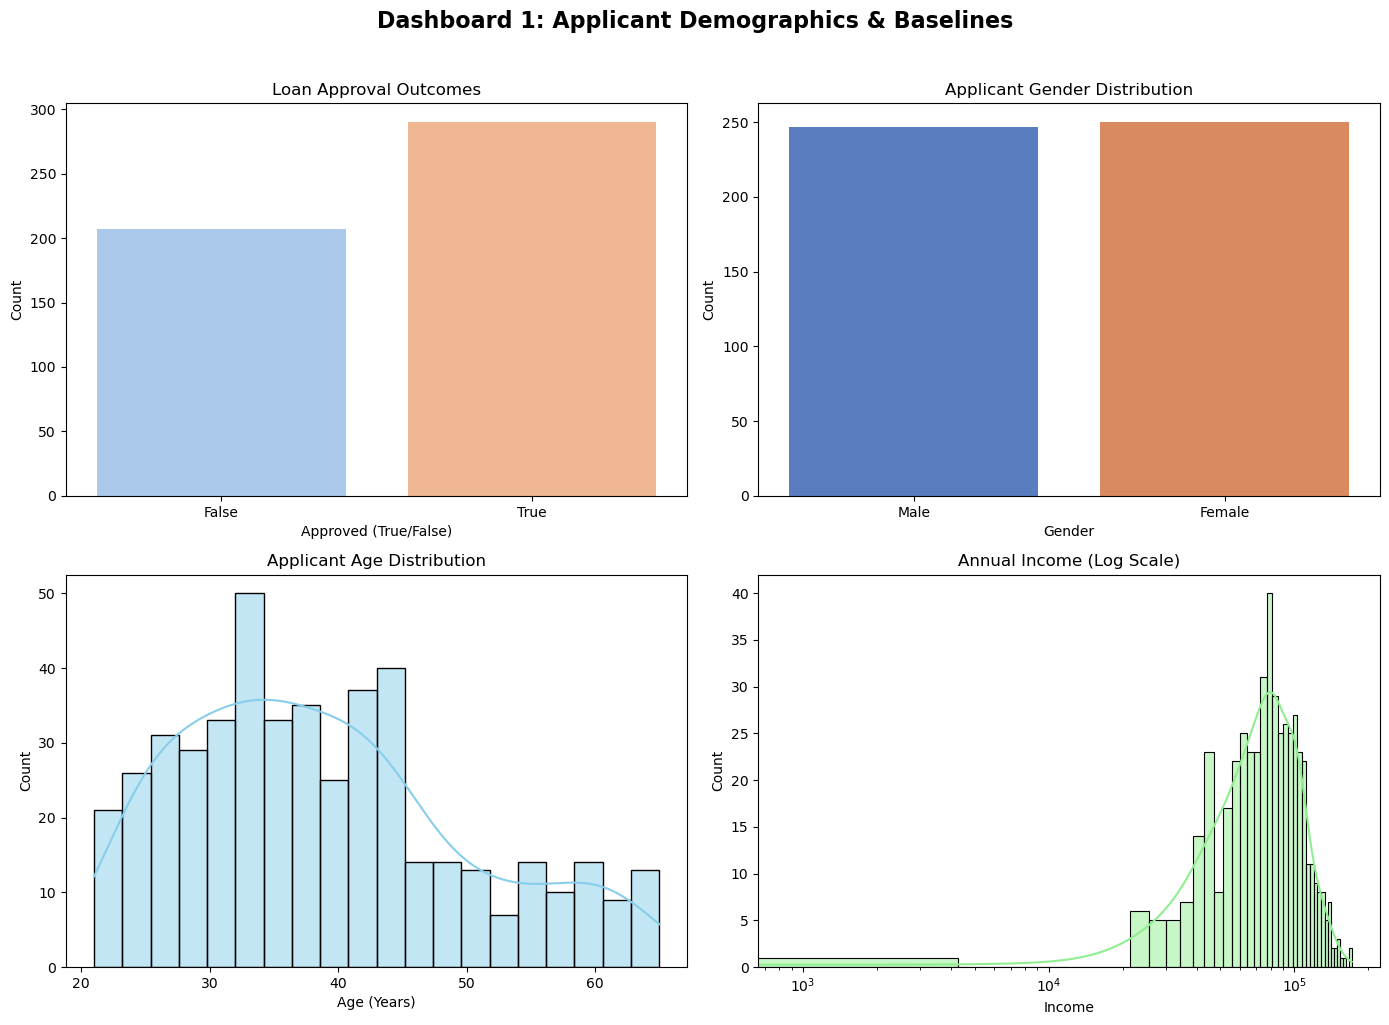

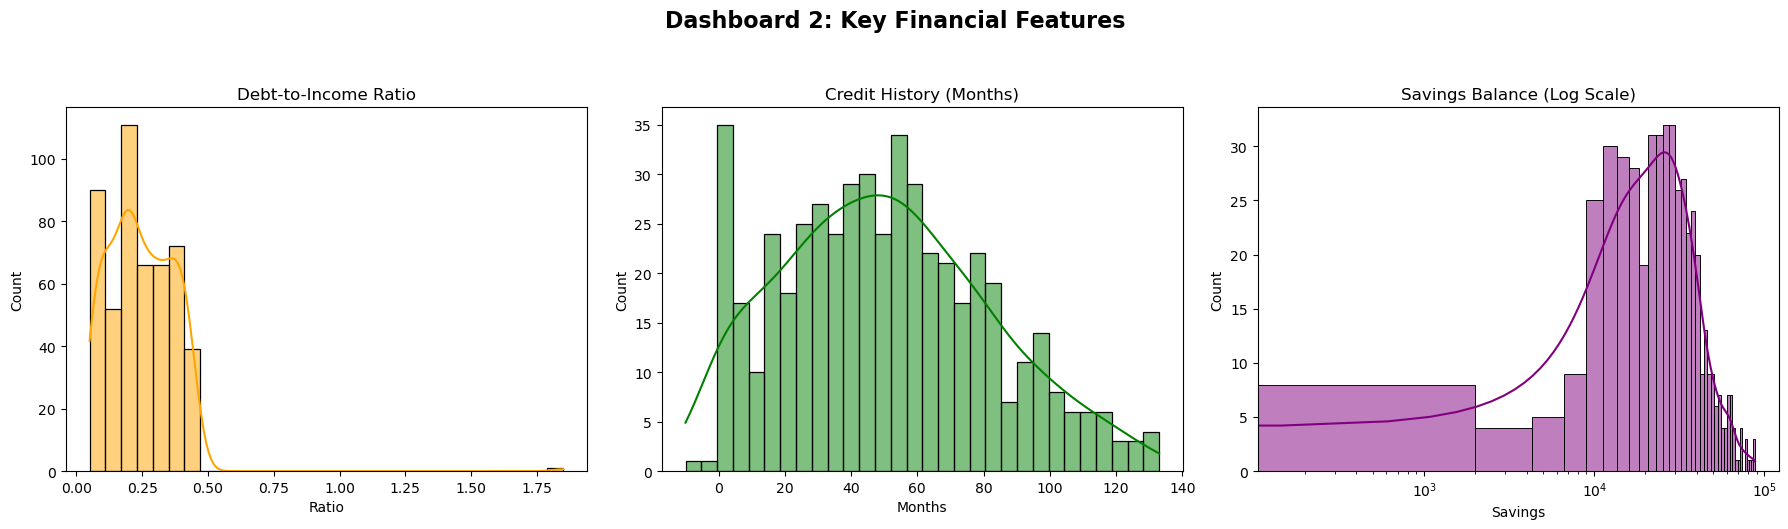

In [208]:
# Dashboard 1: Applicant Demographics & Baselines
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))
fig1.suptitle('Dashboard 1: Applicant Demographics & Baselines', fontsize=16, fontweight='bold', y=1.02)

# 1. Overall Loan Approval Distribution
sns.countplot(
    data=merged_df, 
    x='decision_loan_approved', 
    palette='pastel', 
    ax=axes1[0, 0]
)
axes1[0, 0].set_title('Loan Approval Outcomes')
axes1[0, 0].set_xlabel('Approved (True/False)')
axes1[0, 0].set_ylabel('Count')

# 2. Gender Distribution
eda_gender = merged_df[merged_df['applicant_info_gender'].isin(['Male', 'Female'])]
sns.countplot(
    data=eda_gender, 
    x='applicant_info_gender', 
    palette='muted', 
    ax=axes1[0, 1]
)
axes1[0, 1].set_title('Applicant Gender Distribution')
axes1[0, 1].set_xlabel('Gender')
axes1[0, 1].set_ylabel('Count')

# 3. Age Distribution
sns.histplot(
    data=merged_df, 
    x='age', 
    bins=20, 
    kde=True, 
    color='skyblue', 
    ax=axes1[1, 0]
)
axes1[1, 0].set_title('Applicant Age Distribution')
axes1[1, 0].set_xlabel('Age (Years)')

# 4. Annual Income Distribution (Log Scale)
sns.histplot(
    data=merged_df, 
    x='financials_annual_income', 
    bins=40, 
    kde=True, 
    color='lightgreen', 
    ax=axes1[1, 1]
)
axes1[1, 1].set_title('Annual Income (Log Scale)')
axes1[1, 1].set_xlabel('Income')
axes1[1, 1].set_xscale('log') 

plt.tight_layout()
plt.show()


# Dashboard 2: Key Financial Features
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle('Dashboard 2: Key Financial Features', fontsize=16, fontweight='bold', y=1.05)

# 1. Debt-to-Income Ratio
sns.histplot(
    data=merged_df, 
    x='financials_debt_to_income', 
    bins=30, 
    kde=True, 
    color='orange', 
    ax=axes2[0]
)
axes2[0].set_title('Debt-to-Income Ratio')
axes2[0].set_xlabel('Ratio')

# 2. Credit History Months
sns.histplot(
    data=merged_df, 
    x='financials_credit_history_months', 
    bins=30, 
    kde=True, 
    color='green', 
    ax=axes2[1]
)
axes2[1].set_title('Credit History (Months)')
axes2[1].set_xlabel('Months')

# 3. Savings Balance (Log Scale)
sns.histplot(
    data=merged_df, 
    x='financials_savings_balance', 
    bins=40, 
    kde=True, 
    color='purple', 
    ax=axes2[2]
)
axes2[2].set_title('Savings Balance (Log Scale)')
axes2[2].set_xlabel('Savings')
axes2[2].set_xscale('log') 

plt.tight_layout()
plt.show()

## 2.2. Bivariate Analysis

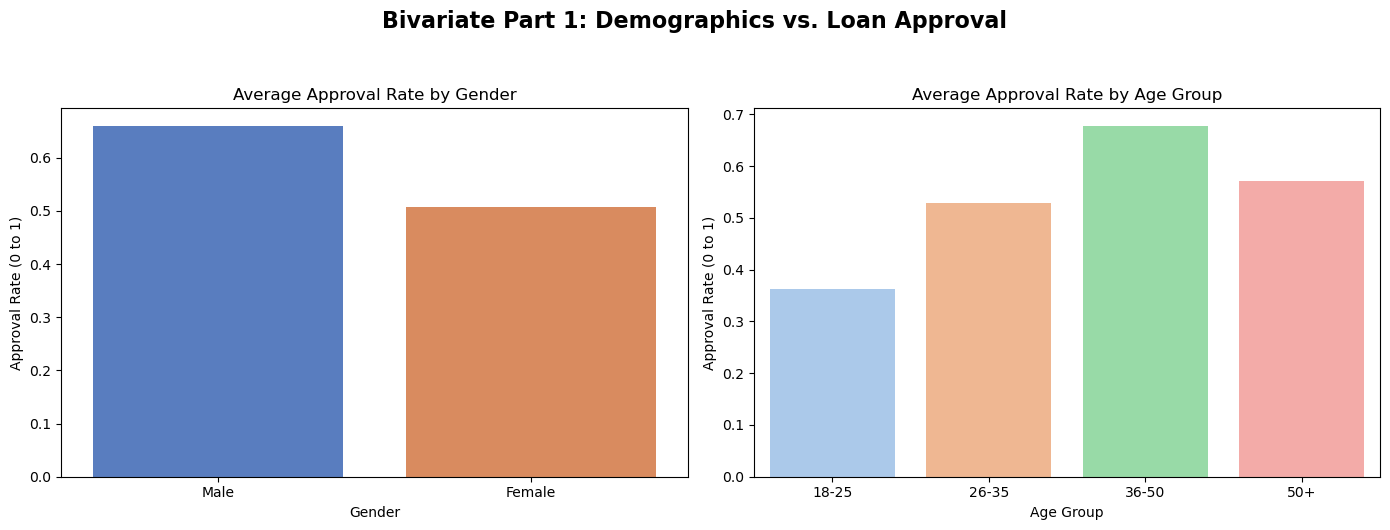

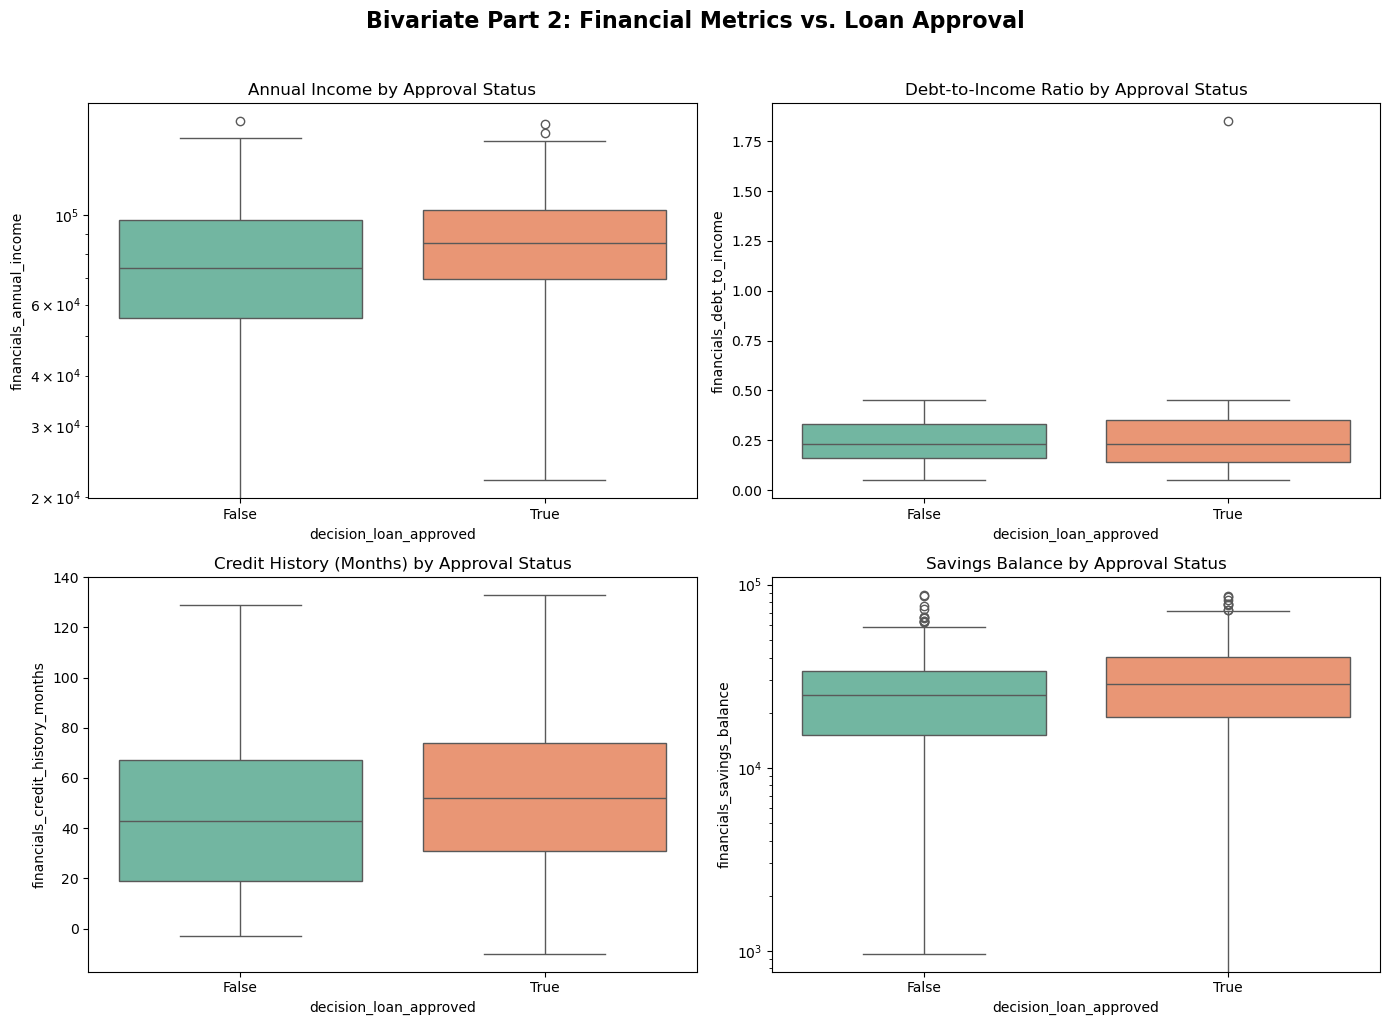

In [209]:
# Dashboard 1: Demographics vs. Loan Approval
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))
fig1.suptitle('Bivariate Part 1: Demographics vs. Loan Approval', fontsize=16, fontweight='bold', y=1.05)

# Filter out 'Unknown' gender for cleaner visuals
eda_gender = merged_df[merged_df['applicant_info_gender'].isin(['Male', 'Female'])]

# 1. Approval Rate by Gender
sns.barplot(
    x='applicant_info_gender', 
    y='decision_loan_approved', 
    data=eda_gender, 
    ax=axes1[0], 
    palette='muted',
    errorbar=None
)
axes1[0].set_title('Average Approval Rate by Gender')
axes1[0].set_ylabel('Approval Rate (0 to 1)')
axes1[0].set_xlabel('Gender')

# 2. Approval Rate by Age Group
sns.barplot(
    x='age_group', 
    y='decision_loan_approved', 
    data=merged_df, 
    ax=axes1[1], 
    palette='pastel',
    errorbar=None
)
axes1[1].set_title('Average Approval Rate by Age Group')
axes1[1].set_ylabel('Approval Rate (0 to 1)')
axes1[1].set_xlabel('Age Group')

plt.tight_layout()
plt.show()


# Dashboard 2: Financial Metrics vs. Loan Approval
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle('Bivariate Part 2: Financial Metrics vs. Loan Approval', fontsize=16, fontweight='bold', y=1.02)

# 1. Income vs Approval (Log Scale)
sns.boxplot(x='decision_loan_approved', y='financials_annual_income', data=merged_df, ax=axes2[0,0], palette='Set2')
axes2[0,0].set_yscale('log')
axes2[0,0].set_title('Annual Income by Approval Status')

# 2. Debt-to-Income vs Approval
sns.boxplot(x='decision_loan_approved', y='financials_debt_to_income', data=merged_df, ax=axes2[0,1], palette='Set2')
axes2[0,1].set_title('Debt-to-Income Ratio by Approval Status')

# 3. Credit History vs Approval
sns.boxplot(x='decision_loan_approved', y='financials_credit_history_months', data=merged_df, ax=axes2[1,0], palette='Set2')
axes2[1,0].set_title('Credit History (Months) by Approval Status')

# 4. Savings Balance vs Approval (Log Scale)
sns.boxplot(x='decision_loan_approved', y='financials_savings_balance', data=merged_df, ax=axes2[1,1], palette='Set2')
axes2[1,1].set_yscale('log')
axes2[1,1].set_title('Savings Balance by Approval Status')

plt.tight_layout()
plt.show()

## 2.3. Multivariate Analysis

### 2.3.1. Initial Correlation Analysis
- We convert our categorical variables to numeric ones for this step
- We use a Seaborn Heatmap for visualization

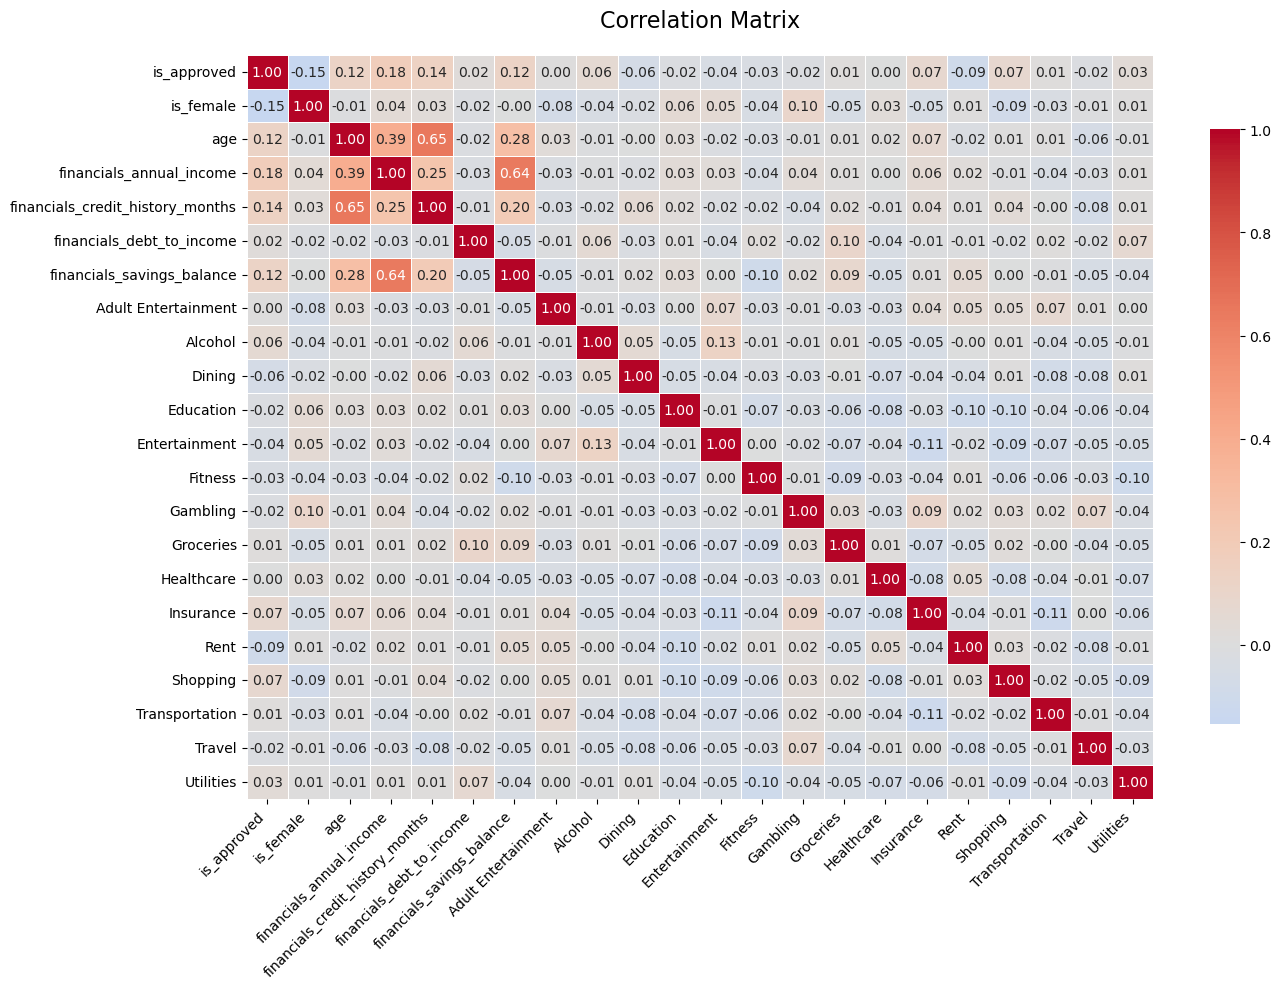

In [207]:
corr_df = merged_df.copy()

# Encode Gender (1 for Female, 0 for Male)
corr_df['is_female'] = (corr_df['applicant_info_gender'] == 'Female').astype(int)

# Encode Loan Approval (1 for True, 0 for False)
corr_df['is_approved'] = corr_df['decision_loan_approved'].astype(int)

# Select the key columns we care about for bias hunting
cols_to_correlate = [
    'is_approved', 'is_female', 'age', 
    'financials_annual_income', 'financials_credit_history_months',
    'financials_debt_to_income', 'financials_savings_balance'
] + list(spending_categories)

correlation_matrix = corr_df[cols_to_correlate].corr()

# Visualizing
plt.figure(figsize=(14, 10))

# Negative correlations are blue and positive are red
sns.heatmap(
    correlation_matrix, 
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Matrix', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2.3.2. Financial Interactions by Gender
- We use Pairplot for this step

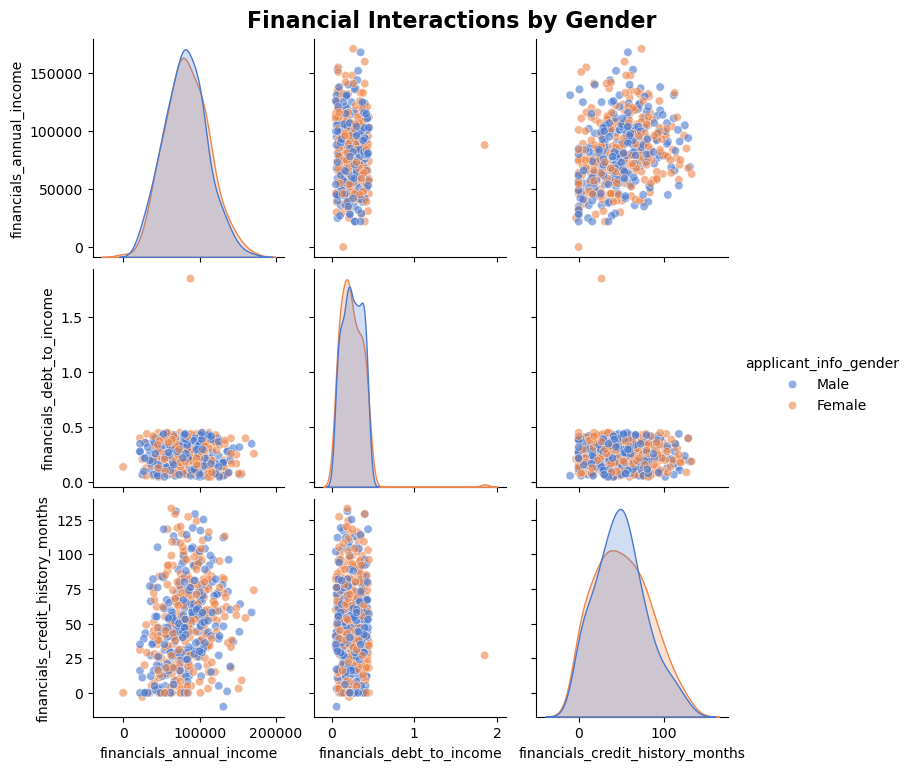

In [210]:
pairplot_cols = [
    'financials_annual_income', 'financials_debt_to_income', 
    'financials_credit_history_months', 'applicant_info_gender'
]

pair_df = merged_df[merged_df['applicant_info_gender'].isin(['Male', 'Female'])][pairplot_cols]

pair_grid = sns.pairplot(
    pair_df, 
    hue='applicant_info_gender', 
    palette='muted', 
    plot_kws={'alpha': 0.6}, 
    diag_kind='kde'
)
pair_grid.fig.suptitle('Financial Interactions by Gender', fontsize=16, fontweight='bold', y=1.02)

plt.show()

### 2.3.3. Log-Regression for Loan Approval
- We fit a Logistic Regression model to predict `decision_loan_approved`. 

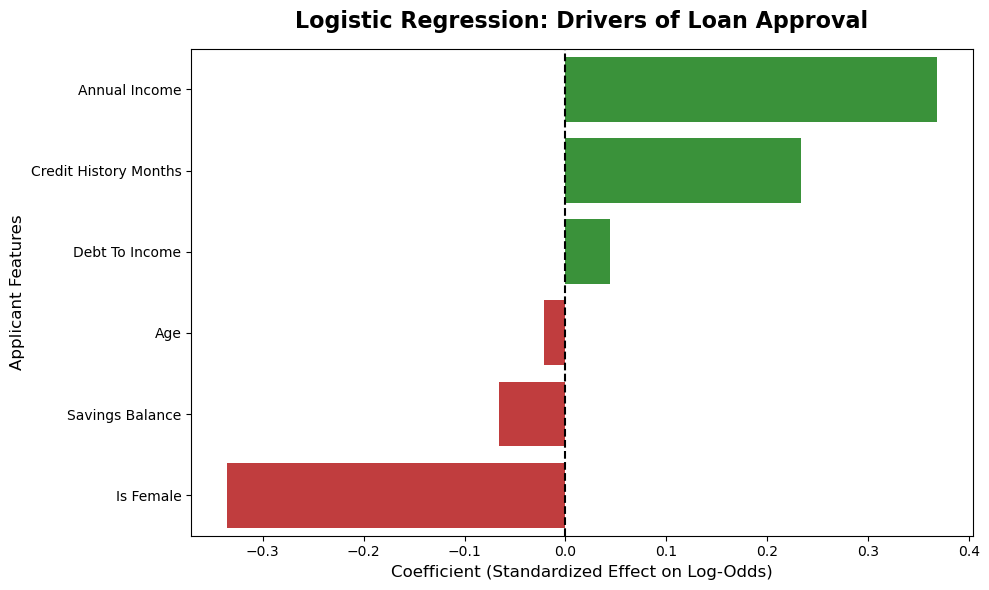

Green Bars: These variables increase the chances of loan approval.
Red Bars: These variables INCREASE the chances of loan rejection.


In [211]:
# Features
log_features = [
    'financials_annual_income', 'financials_debt_to_income', 
    'financials_credit_history_months', 'financials_savings_balance', 'age'
]
log_df = merged_df[log_features + ['applicant_info_gender', 'decision_loan_approved']].dropna().copy()

# Encode gender
log_df['is_female'] = (log_df['applicant_info_gender'] == 'Female').astype(int)
log_features.append('is_female')

X = log_df[log_features]
y = log_df['decision_loan_approved'].astype(int)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_scaled, y)

coef_df = pd.DataFrame({
    'Feature': log_features,
    'Coefficient': log_reg.coef_[0]
})

coef_df['Feature'] = coef_df['Feature'].str.replace('financials_', '').str.replace('_', ' ').str.title()
coef_df = coef_df.sort_values('Coefficient', ascending=False)

# Visualize coefficients
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ca02c' if c > 0 else '#d62728' for c in coef_df['Coefficient']]

sns.barplot(
    x='Coefficient', 
    y='Feature', 
    data=coef_df, 
    palette=colors,
    ax=ax
)

ax.set_title('Logistic Regression: Drivers of Loan Approval', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Coefficient (Standardized Effect on Log-Odds)', fontsize=12)
ax.set_ylabel('Applicant Features', fontsize=12)

# Add a vertical line
ax.axvline(0, color='black', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()

print("Green Bars: These variables increase the chances of loan approval.")
print("Red Bars: These variables INCREASE the chances of loan rejection.")

### 2.3.4. Random Forrest

While the Logistic Regression revealed the direction of feature effects, real-world algorithms often utilize complex, non-linear interactions. To try and capture these dynamics, we fit a Random Forest Classifier.

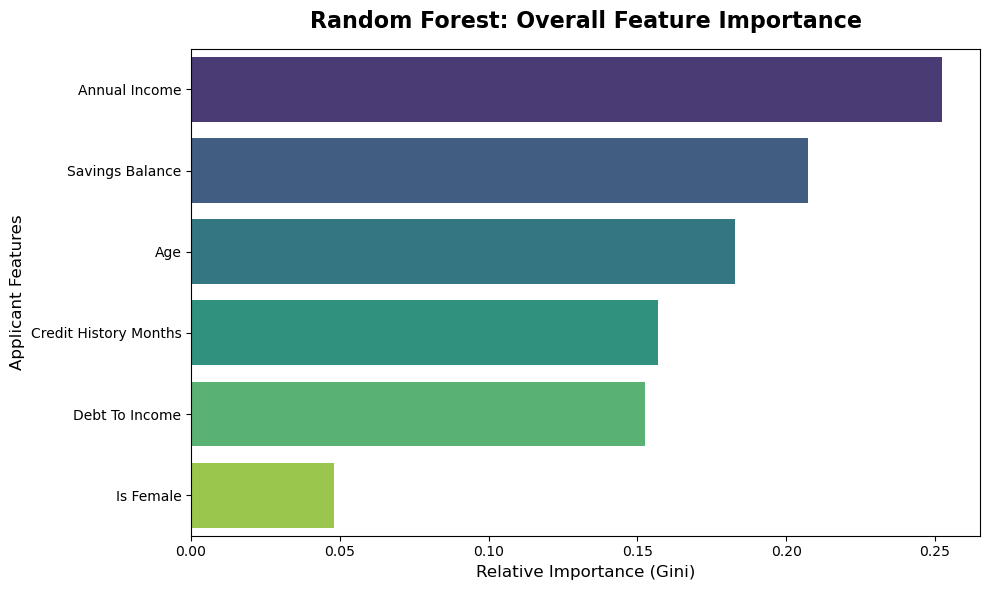

Bar lenght increase: The algorithm relied heavily on this feature to separate Approvals from Rejections.


In [212]:
# Prepare data 
rf_features = [
    'financials_annual_income', 'financials_debt_to_income', 
    'financials_credit_history_months', 'financials_savings_balance', 'age', 'is_female'
]

X_rf = log_df[rf_features]
y_rf = log_df['decision_loan_approved'].astype(int)

# Fit Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_rf, y_rf)

rf_importances = pd.DataFrame({
    'Feature': rf_features,
    'Importance': rf_model.feature_importances_
})

rf_importances['Feature'] = rf_importances['Feature'].str.replace('financials_', '').str.replace('_', ' ').str.title()
rf_importances = rf_importances.sort_values('Importance', ascending=False)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x='Importance', 
    y='Feature', 
    data=rf_importances, 
    palette='viridis',
    ax=ax
)

ax.set_title('Random Forest: Overall Feature Importance', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Relative Importance (Gini)', fontsize=12)
ax.set_ylabel('Applicant Features', fontsize=12)

plt.tight_layout()
plt.show()

print("Bar lenght increase: The algorithm relied heavily on this feature to separate Approvals from Rejections.")

# 3. Bias Analysis

## 3.1. Gender Bias Analysis

In this section, the gender bias in the dataset will be thoroughly examined, using the Disparate Impact (DI) Ratio and Approval Rate per age group as follows:

$$P(\text{Approved} \mid \text{Age} \in g) = \frac{\sum I(\text{Approved} \cap \text{Age} \in g)}{\sum I(\text{Age} \in g)}$$

$$DI_{\text{Gender}} = \frac{P(\text{Approved} \mid \text{Gender} = \text{Female})}{P(\text{Approved} \mid \text{Gender} = \text{Male})}$$

### 3.1.1. Approval Rates by Gender
- 'decision_loan_approved' is a boolean (True/False).
- Taking the mean() of a boolean column gives us the exact percentage of True values (the approval rate).

In [213]:
gender_approval = merged_df.groupby('applicant_info_gender')['decision_loan_approved'].mean().reset_index()
gender_approval.rename(columns={'decision_loan_approved': 'approval_rate'}, inplace=True)

print("Approval Rates by Gender:")
print(gender_approval.to_string(index=False))
print("\n")

Approval Rates by Gender:
applicant_info_gender  approval_rate
               Female       0.508000
                 Male       0.659919




### 3.1.2. Calculate Disparate Impact (DI) Ratio
- We will test Female as the potentially unprivileged group against Male as the privileged group
- The four-fifths rule states a DI < 0.8 indicates potential disparate impact

In [214]:
rate_male = gender_approval[gender_approval['applicant_info_gender'] == 'Male']['approval_rate'].values[0]
rate_female = gender_approval[gender_approval['applicant_info_gender'] == 'Female']['approval_rate'].values[0]

di_ratio_gender = rate_female / rate_male

print(f"Disparate Impact Analysis:")
print(f"Disparate Impact (DI) Ratio (Female/Male): {di_ratio_gender:.4f}")

if di_ratio_gender < 0.8:
    print("DI Ratio is below 0.8. This violates the four-fifths rule and indicates potential gender bias!")
else:
    print("DI Ratio is 0.8 or above. No strict disparate impact flagged by the four-fifths rule.")

Disparate Impact Analysis:
Disparate Impact (DI) Ratio (Female/Male): 0.7698
DI Ratio is below 0.8. This violates the four-fifths rule and indicates potential gender bias!


### 3.1.3. Visualizing the Results
- Horizontal dashed line for the 80% threshold

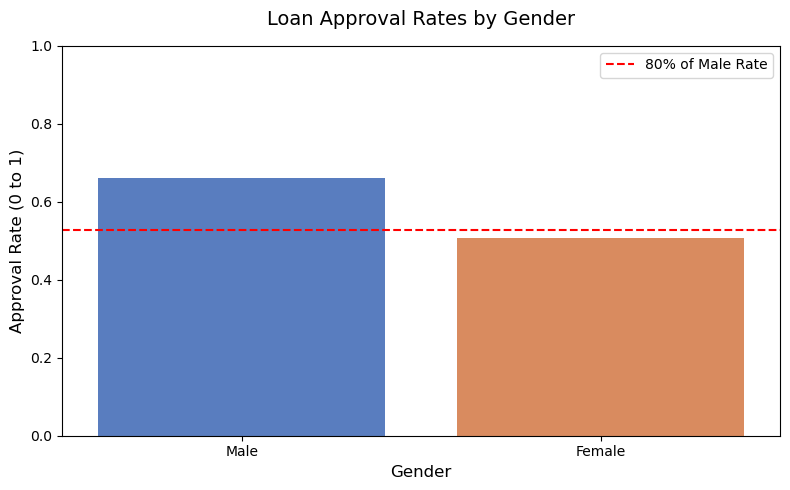

In [215]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    x='applicant_info_gender', 
    y='approval_rate', 
    data=gender_approval, 
    palette='muted',
    order=['Male', 'Female'],
    ax=ax
)

ax.set_title('Loan Approval Rates by Gender', fontsize=14, pad=15)
ax.set_ylabel('Approval Rate (0 to 1)', fontsize=12)
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylim(0, 1) 

# Add horizontal threshold line 
ax.axhline(y=rate_male * 0.8, color='red', linestyle='--', label='80% of Male Rate')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 3.2. Age-Based Discrimination Analysis

In this section, to investigate age-based bias, we segment the continuous age variable into discrete generational groups ($g$) and compare the probability of approval across these. The math is as follows:

$$P(\text{Approved} \mid \text{Age} \in g) = \frac{\sum I(\text{Approved} \cap \text{Age} \in g)}{\sum I(\text{Age} \in g)}$$

$$DI_{\text{Age}} = \frac{P(\text{Approved} \mid \text{Age} \in [18, 25))}{P(\text{Approved} \mid \text{Age} \in [36, 50))}$$

### 3.2.1 Approval Rates by Age Bins 

In [216]:
age_approval = merged_df.groupby('age_group')['decision_loan_approved'].mean().reset_index()
age_approval.rename(columns={'decision_loan_approved': 'approval_rate'}, inplace=True)

print("Approval Rates by Age Group:")
print(age_approval.to_string(index=False))
print("\n")

Approval Rates by Age Group:
age_group  approval_rate
    18-25       0.361702
    26-35       0.527950
    36-50       0.677596
      50+       0.571429




### 3.2.2. Calculate Disparate Impact (DI) Ratio
- We determine the DI Ratio for Age (Youngest vs. Prime Earning Years)
- We test the 18-25 group (potentially unprivileged) against the 36-50 group (potentially privileged)

In [217]:
rate_young = age_approval[age_approval['age_group'] == '18-25']['approval_rate'].values[0]
rate_middle = age_approval[age_approval['age_group'] == '36-50']['approval_rate'].values[0]

if rate_middle > 0:
    di_ratio_age = rate_young / rate_middle
    print(f"Age Disparate Impact (18-25 vs 36-50):")
    print(f"DI Ratio: {di_ratio_age:.4f}")
    if di_ratio_age < 0.8:
        print("Potential age-based bias detected against younger applicants (< 0.8)")
    else:
        print("No strict DI flagged for this specific age comparison.")
else:
    print("Cannot calculate DI: Privileged group approval rate is 0.")

Age Disparate Impact (18-25 vs 36-50):
DI Ratio: 0.5338
Potential age-based bias detected against younger applicants (< 0.8)


### 3.2.3. Visualizing the Results
- Horizontal dashed line for the '36-50' group's 80% threshold

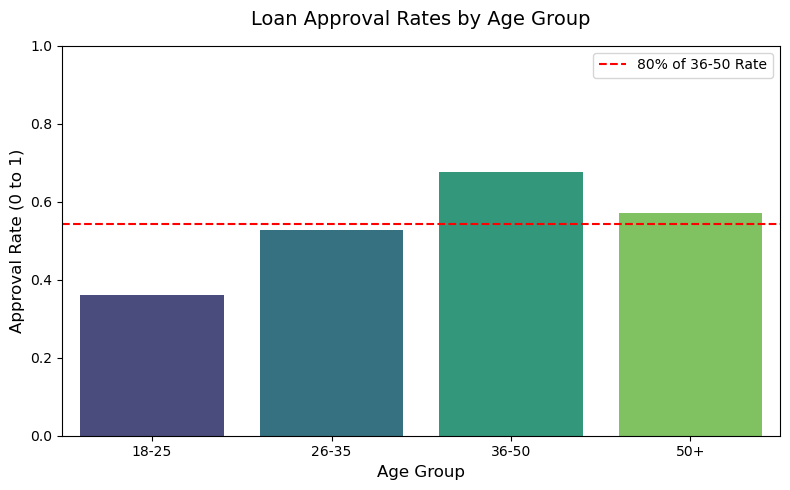

In [218]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    x='age_group', 
    y='approval_rate', 
    data=age_approval, 
    palette='viridis',
    ax=ax
)

ax.set_title('Loan Approval Rates by Age Group', fontsize=14, pad=15)
ax.set_ylabel('Approval Rate (0 to 1)', fontsize=12)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylim(0, 1)

# Add horizontal threshold line
if rate_middle > 0:
    ax.axhline(y=rate_middle * 0.8, color='red', linestyle='--', label='80% of 36-50 Rate')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 3.3. Proxy Discrimination Analysis

A non-protected attribute $X_{proxy}$ (e.g., ZIP code, spending category) acts as a proxy for a protected attribute $A$ (e.g., Gender) if it is highly correlated with $A$ and significantly impacts the decision outcome $Y$.

To measure the relationship between a continuous spending category and the binary loan approval outcome, we use the point-biserial correlation coefficient:
$$r_{pb} = \frac{M_1 - M_0}{s_n} \sqrt{\frac{n_1 n_0}{n^2}}$$
*(Where $M_1$ and $M_0$ are the mean spending of the approved and rejected groups respectively).*

### 3.3.1. Geographic Proxy Analysis (ZIP Codes)
- We aggregate the data by ZIP code
- We have a filter for ZIP codes with at least 5 applicants to reduce statistical noise

In [219]:
# Aggregation
zip_analysis = merged_df.groupby('applicant_info_zip_code').agg(
    applicant_count=('app_id', 'count'),
    approval_rate=('decision_loan_approved', 'mean'),
    female_ratio=('applicant_info_gender', lambda x: (x == 'Female').mean())
).reset_index()

# Filter for ZIP codes
zip_analysis = zip_analysis[zip_analysis['applicant_count'] >= 5]

# Calculate Pearson correlation
zip_corr, zip_pval = stats.pearsonr(zip_analysis['female_ratio'], zip_analysis['approval_rate'])
print(f"Correlation between Female Ratio and ZIP Approval Rate: {zip_corr:.3f} (p-value: {zip_pval:.3f})")

if zip_corr < -0.3 and zip_pval < 0.05:
    print("Strong negative correlation found! ZIP code might be acting as a proxy for Gender.")
else:
    print("No strong, statistically significant proxy effect found for ZIP codes overall.")
print("\n")

Correlation between Female Ratio and ZIP Approval Rate: -0.222 (p-value: 0.361)
No strong, statistically significant proxy effect found for ZIP codes overall.




### 3.3.2. Behavioral Proxy Analysis (Spending Categories)

In [220]:
proxy_results = []

for category in spending_categories:
    spend_by_gender = merged_df.groupby('applicant_info_gender')[category].mean()
    male_spend = spend_by_gender.get('Male', 0)
    female_spend = spend_by_gender.get('Female', 0)
    
    # Correlation between spending in this category and getting approved
    corr, p_val = stats.pointbiserialr(merged_df[category], merged_df['decision_loan_approved'])
    
    proxy_results.append({
        'Category': category,
        'Male_Avg_Spend': male_spend,
        'Female_Avg_Spend': female_spend,
        'Approval_Correlation': corr
    })

proxy_df = pd.DataFrame(proxy_results)
proxy_df['Gender_Difference'] = proxy_df['Female_Avg_Spend'] - proxy_df['Male_Avg_Spend']

# Sort by the most negatively correlated with approval (categories that get people rejected)
proxy_df = proxy_df.sort_values('Approval_Correlation', ascending=True)

print("Spending Categories impacting Loan Approval (Negative = Higher Rejection):")
print()
print(proxy_df[['Category', 'Approval_Correlation', 'Male_Avg_Spend', 'Female_Avg_Spend']].head(5).to_string(index=False))




Spending Categories impacting Loan Approval (Negative = Higher Rejection):

     Category  Approval_Correlation  Male_Avg_Spend  Female_Avg_Spend
         Rent             -0.094039       60.809717            63.480
       Dining             -0.062054       66.182186            57.556
Entertainment             -0.039341       60.441296            79.608
      Fitness             -0.028824       69.546559            56.008
       Travel             -0.020594       81.307692            77.556


### 3.3.3. Visualizing the Results
- Plot 1: ZIP Code Proxy
- Plot 2: Top Proxy Spending Category (The most negative correlation)

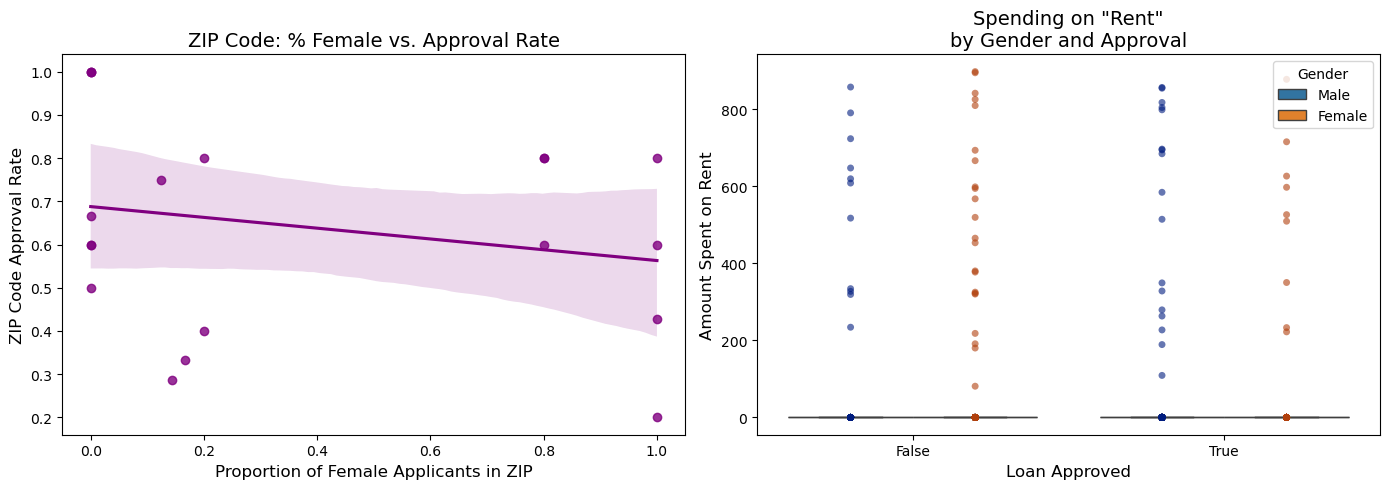

In [221]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1
sns.regplot(
    x='female_ratio', 
    y='approval_rate', 
    data=zip_analysis, 
    ax=axes[0],
    color='purple'
)
axes[0].set_title('ZIP Code: % Female vs. Approval Rate', fontsize=14)
axes[0].set_xlabel('Proportion of Female Applicants in ZIP', fontsize=12)
axes[0].set_ylabel('ZIP Code Approval Rate', fontsize=12)

# Plot 2
top_proxy_category = proxy_df.iloc[0]['Category']
sns.boxplot(
    x='decision_loan_approved', 
    y=top_proxy_category, 
    hue='applicant_info_gender', 
    data=merged_df,
    ax=axes[1],
    showfliers=False
)

sns.stripplot(
    x='decision_loan_approved', 
    y=top_proxy_category, 
    hue='applicant_info_gender', 
    data=merged_df,
    ax=axes[1],
    palette='dark',
    dodge=True,
    alpha=0.6,
    jitter=False
)

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles[:2], labels[:2], title='Gender', loc='upper right')

axes[1].set_title(f'Spending on "{top_proxy_category}"\nby Gender and Approval', fontsize=14)
axes[1].set_xlabel('Loan Approved', fontsize=12)
axes[1].set_ylabel(f'Amount Spent on {top_proxy_category}', fontsize=12)

plt.tight_layout()
plt.show()

## 3.4. Interaction Effects (Age and Gender)

To identify compounding biases, we calculate the joint probability of loan approval given the intersection of two protected or sensitive attributes (e.g., Gender and Age Group).

$$P(\text{Approved} \mid \text{Gender} = c_1 \cap \text{Age} \in g)$$

By comparing these intersectional rates, we can identify if specific subgroups (e.g., young females) face disproportionate disparate impact compared to the privileged baseline.

### 3.4.1. Calculating Interaction Effects
- We filter out 'Unknown' genders so we don't get NaNs from empty groups

In [222]:
interaction_approval = merged_df.groupby(['age_group', 'applicant_info_gender'])['decision_loan_approved'].agg(
    applicant_count='count',
    approval_rate='mean'
).reset_index()

#Identify the most penalized subgroup
worst_group = interaction_approval.sort_values('approval_rate').iloc[0]

print(interaction_approval.to_string(index=False))
print("\n")
print(f"Most Penalized Subgroup: {worst_group['age_group']} year old {worst_group['applicant_info_gender']}s "
      f"with an approval rate of {worst_group['approval_rate']:.2f}")

age_group applicant_info_gender  applicant_count  approval_rate
    18-25                Female               26       0.346154
    18-25                  Male               21       0.380952
    26-35                Female               82       0.426829
    26-35                  Male               79       0.632911
    36-50                Female               87       0.620690
    36-50                  Male               96       0.729167
      50+                Female               42       0.500000
      50+                  Male               35       0.657143


Most Penalized Subgroup: 18-25 year old Females with an approval rate of 0.35


### 3.4.2. Visualizing the results

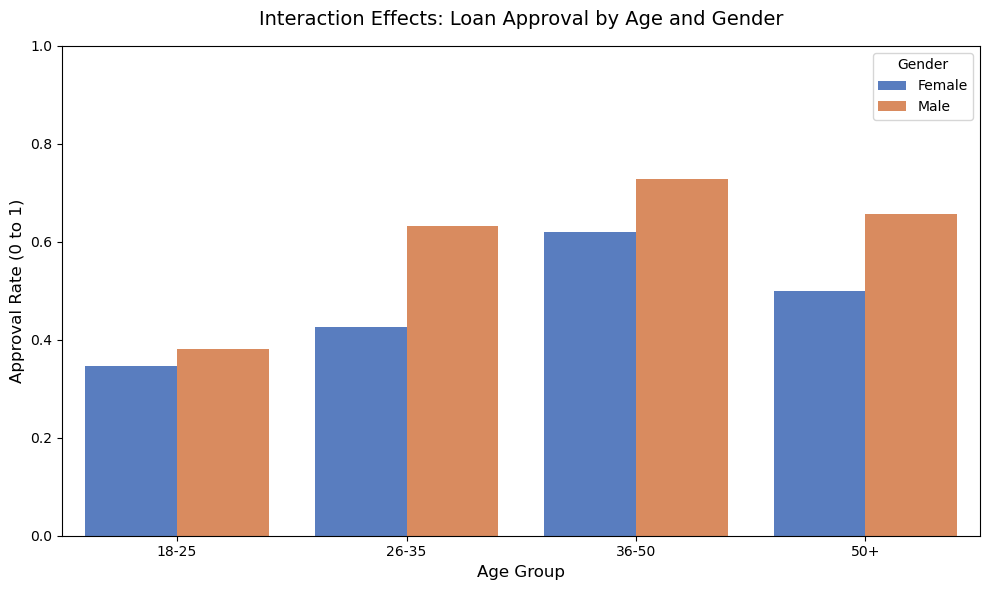

In [223]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x='age_group', 
    y='approval_rate', 
    hue='applicant_info_gender',
    data=interaction_approval, 
    palette='muted',
    ax=ax
)

ax.set_title('Interaction Effects: Loan Approval by Age and Gender', fontsize=14, pad=15)
ax.set_ylabel('Approval Rate (0 to 1)', fontsize=12)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylim(0, 1)

ax.legend(title='Gender', loc='upper right')

plt.tight_layout()
plt.show()

## 3.5. Statistical Fairness Metrics (Fairlearn)

To  quantify the bias detected in previous steps, we utilize the `fairlearn` library to calculate standard fairness metrics. We focus on Demographic Parity, which assumes that the probability of a positive outcome should be independent of the sensitive feature $A$.

$$DPD = | P(\text{Approved} \mid A=\text{unprivileged}) - P(\text{Approved} \mid A=\text{privileged}) |$$

$$DPR = \frac{P(\text{Approved} \mid A=\text{unprivileged})}{P(\text{Approved} \mid A=\text{privileged})}$$

In [224]:
# 1. Filter out 'Unknown' to avoid Fairlearn causing errors
fairness_df = merged_df[merged_df['applicant_info_gender'].isin(['Male', 'Female'])].copy()

# 2. Define target and sensitive features
y_pred = fairness_df['decision_loan_approved'].astype(int) 
sensitive_features = fairness_df['applicant_info_gender']

# 3. Calculation
dpd = demographic_parity_difference(
    y_true=y_pred, 
    y_pred=y_pred, 
    sensitive_features=sensitive_features
)

dpr = demographic_parity_ratio(
    y_true=y_pred, 
    y_pred=y_pred, 
    sensitive_features=sensitive_features
)

print(f"Protected Attribute: Gender (Male vs. Female)\n")

print(f"1. Demographic Parity Difference (DPD): {dpd:.4f}")
if dpd > 0.1:
    print("High parity difference detected. (Ideal is close to 0.0)")
else:
    print("Parity difference is within acceptable ranges.")

print(f"\n2. Demographic Parity Ratio (DPR / Disparate Impact): {dpr:.4f}")
if dpr < 0.8:
    print("Fails the Four-Fifths Rule (Ratio < 0.8).")
else:
    print("Passes the Four-Fifths Rule.")

Protected Attribute: Gender (Male vs. Female)

1. Demographic Parity Difference (DPD): 0.1519
High parity difference detected. (Ideal is close to 0.0)

2. Demographic Parity Ratio (DPR / Disparate Impact): 0.7698
Fails the Four-Fifths Rule (Ratio < 0.8).
